# Self-interacting neutrinos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import classy

In [2]:
##Define cosmologies:

dict_general = {
    # General & Background
    'h': 0.67810,
    'T_cmb': 2.7255,
    'omega_b': 0.02238280,
    'omega_cdm': 0.1201075,
    'N_ur': 3.044,
    'Omega_k': 0.,
    'YHe': 'BBN',
    'recombination': 'recfast',
    
    # Reionization
    'reio_parametrization': 'reio_camb',
    'z_reio': 7.6711,
    'reionization_exponent': 1.5,
    'reionization_width': 0.5,
    'helium_fullreio_redshift': 3.5,
    'helium_fullreio_width': 0.5,
    
    # Perturbations & Output types
    'output': 'tCl,pCl,lCl,mPk',
    'modes': 's',
    'ic': 'ad',
    'gauge': 'synchronous',
    'lensing': 'yes',
    
    # Primordial Spectrum
    'k_pivot': 0.05,
    'A_s': 2.100549e-09,
    'n_s': 0.9660499,
    'alpha_s': 0.,
    
    # Spectra Limits & LSS
    'l_max_scalars': 2500,
    'P_k_max_h/Mpc': 1.,
    'z_pk': 0,
    
    # Verbosity
    'input_verbose': 0,
    'background_verbose': 0,
    'thermodynamics_verbose': 0,
    'perturbations_verbose': 0,
    'transfer_verbose': 0,
    'primordial_verbose': 0,
    'lensing_verbose': 0,
    'output_verbose': 0,
    'back_integration_stepsize': 1e-3,
    'perturb_integration_stepsize': 1e-3
}



# Make some helper functions for cleaner code in the notebook:

def run_cosmo(classy_version, dict_in):
    model = classy_version.Class()
    model.set(dict_in)
    model.compute()
    return model

def plot_Cl_TT(model, ax = None,**kwargs):

    # Get the computed data dictionary
    cl = model.lensed_cl(2500)
    l = cl['ell']
    # Compute C_l = l(l+1)C_l / 2pi (in muK^2)
    factor = l * (l + 1) / (2 * np.pi) * 1e12
    cl_TT = factor * cl['tt']

    if ax is not None:
        ax.plot(l, cl_TT, **kwargs)

    return l, cl_TT




## Running interacting Non-Cold-Dark-Matter in CLASS++:
We can start by running the LCDM model as a baseline:

In [3]:
model_LCDM = run_cosmo(classy, {**dict_general})

To activate self-interacting NCDM, declare a named instance with dot-syntax: `<instance>.type = ncdm_self_interacting`, then set its parameters as `<instance>.<name>`.

In [4]:
## We can define the parameters for the NCDM model and run it:
dict_ncdm = {
        'nui1.type': 'ncdm_self_interacting',
        'nui1.m': 0.01,
        'nui1.T': 0.71611,
        'nui1.deg': 1,
        'nui1.Omega': 0.001,
        'nui1.ksi': 0.
        }

model_NCDM = run_cosmo(classy, {**dict_general, **dict_ncdm})

If we want, we can also define multiple interacting NCDM species: each named instance is independent.

In [5]:
dict_ncdm_multiple_species = {
        'nui1.type': 'ncdm_self_interacting',
        'nui1.m': 0.1,
        'nui1.T': 0.71611,
        'nui1.deg': 1,
        'nui1.Omega': 0.001,
        'nui1.ksi': 0.,
        'nui2.type': 'ncdm_self_interacting',
        'nui2.m': 0.2,
        'nui2.T': 0.71611,
        'nui2.deg': 1,
        'nui2.Omega': 0.001,
        'nui2.ksi': 0.
        }

model_NCDM_multiple_species = run_cosmo(classy, {**dict_general, **dict_ncdm_multiple_species})

<>:75: SyntaxWarning: invalid escape sequence '\L'
<>:75: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_255259/1657669011.py:75: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')
/tmp/ipykernel_255259/1657669011.py:46: RuntimeWarning: invalid value encountered in divide
  (cls_ncdm / cls_LCDM - 1) * 100,


Text(0.5, 1.0, 'Relative Difference to $\\Lambda$CDM')

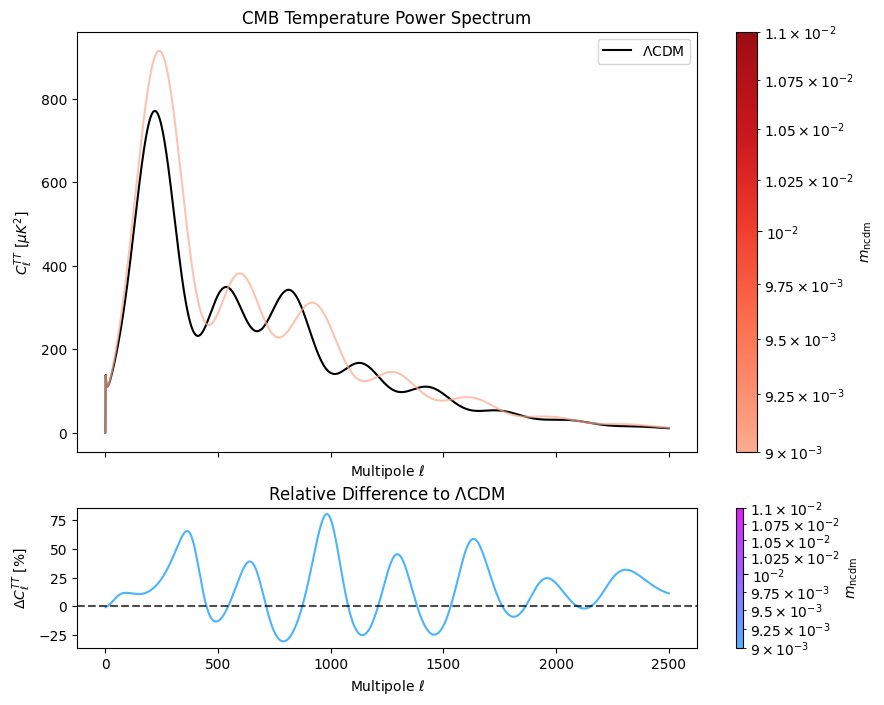

In [6]:
N = 1
m_ncdm_values = np.logspace(-2, 3, N)


fig, axs = plt.subplots(2,1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})



# --- Colormap setup ---
# Restrict range to avoid very light colors
def truncate_cmap(cmap, minval=0.3, maxval=0.9, n=100):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

cmap_ncdm = truncate_cmap(cm.Reds)
cmap_ratio = truncate_cmap(cm.cool)

norm = mcolors.LogNorm(vmin=m_ncdm_values.min(), vmax=m_ncdm_values.max())


ls_LCDM, cls_LCDM = plot_Cl_TT(model_LCDM, ax=axs[0], label=r'$\Lambda$CDM', color='black')

for m_ncdm_value in m_ncdm_values:
    dict_ncdm_local = {**dict_general, **dict_ncdm, 'nui1.m': m_ncdm_value}


    model_ncdm_local = classy.Class()
    model_ncdm_local.set(dict_ncdm_local)
    model_ncdm_local.compute()

    color_ncdm = cmap_ncdm(norm(m_ncdm_value))
    color_ratio = cmap_ratio(norm(m_ncdm_value))


    ls_ncdm, cls_ncdm = plot_Cl_TT(
        model_ncdm_local, axs[0],
        color=color_ncdm,
        alpha = 0.7
    )


    axs[1].plot(
        ls_ncdm,
        (cls_ncdm / cls_LCDM - 1) * 100,
        color=color_ratio
    )


axs[1].axhline(0, color='black', linestyle='--', alpha=0.7)

# --- Colorbars ---
sm_ncdm = cm.ScalarMappable(cmap=cmap_ncdm, norm=norm)
sm_ncdm.set_array([])
cbar_ncdm = fig.colorbar(sm_ncdm, ax=axs[0])
cbar_ncdm.set_label(r'$m_{\mathrm{ncdm}}$')



sm_ratio = cm.ScalarMappable(cmap=cmap_ratio, norm=norm)
sm_ratio.set_array([])
cbar_ratio = fig.colorbar(sm_ratio, ax=axs[1])
cbar_ratio.set_label(r'$m_{\mathrm{ncdm}}$')


# -------Axes labels and titles-------
axs[0].set_xlabel(r'Multipole $\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}$ [$\mu K^2$]')
axs[0].set_title('CMB Temperature Power Spectrum')
axs[0].legend()

axs[1].set_xlabel(r'Multipole $\ell$')
axs[1].set_ylabel(r'$\Delta C_\ell^{TT}$ [%]')
axs[1].set_title('Relative Difference to $\Lambda$CDM')

<>:73: SyntaxWarning: invalid escape sequence '\L'
<>:73: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_255259/507668465.py:73: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')
/tmp/ipykernel_255259/507668465.py:44: RuntimeWarning: invalid value encountered in divide
  (cls_ncdm / cls_LCDM - 1) * 100,
/tmp/ipykernel_255259/507668465.py:73: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')


CosmoComputationError: 

Error in Class: thermodynamics_init(L:345) :error in thermodynamics_helium_from_bbn();
=>thermodynamics_helium_from_bbn(L:1690) :condition (DeltaNeff > deltaN[num_deltaN-1]) is true; You have asked for an unrealistic high value of Delta N_eff = 1.679823e-322. The corresponding value of the primordial helium fraction cannot be found in the interpolation table. If you really want this value, you should fix YHe to a given value rather than to BBN

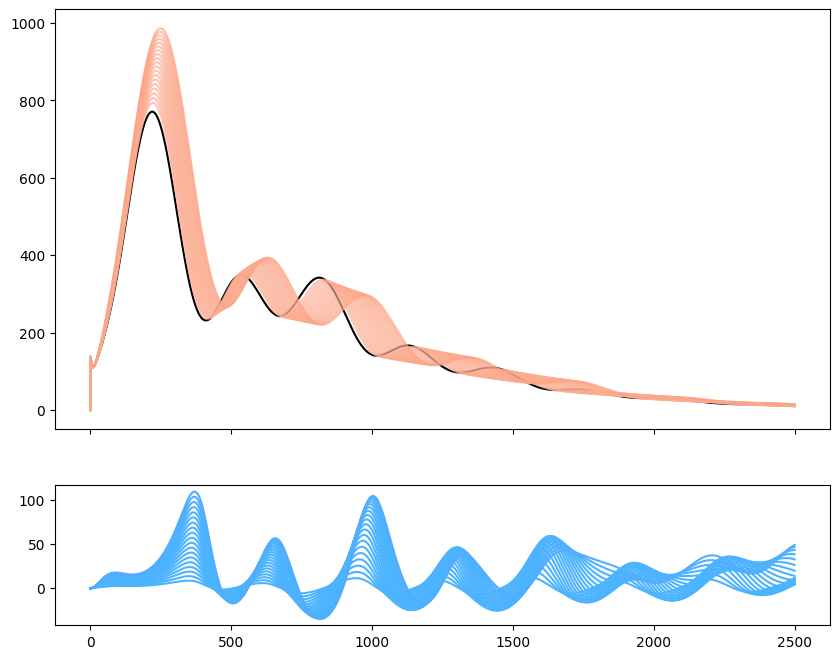

In [9]:
N = 25
T_ncdm_values = np.linspace(0.1, 1.5, N)

fig, axs = plt.subplots(2,1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})



# --- Colormap setup ---
# Restrict range to avoid very light colors
def truncate_cmap(cmap, minval=0.3, maxval=0.9, n=100):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

cmap_ncdm = truncate_cmap(cm.Reds)
cmap_ratio = truncate_cmap(cm.cool)

norm = mcolors.Normalize(vmin=T_ncdm_values.min(), vmax=T_ncdm_values.max())

ls_LCDM, cls_LCDM = plot_Cl_TT(model_LCDM, ax=axs[0], label=r'$\Lambda$CDM', color='black')

for T_ncdm_value in T_ncdm_values:
    # Fix YHe: at large T_ncdm the implied Delta N_eff leaves the BBN table
    dict_ncdm_local = {**dict_general, **dict_ncdm, 'nui1.T': T_ncdm_value, 'YHe': 0.245}


    model_ncdm_local = classy.Class()
    model_ncdm_local.set(dict_ncdm_local)
    model_ncdm_local.compute()

    color_ncdm = cmap_ncdm(norm(T_ncdm_value))
    color_ratio = cmap_ratio(norm(T_ncdm_value))


    ls_ncdm, cls_ncdm = plot_Cl_TT(
        model_ncdm_local, axs[0],
        color=color_ncdm,
        alpha = 0.7
    )


    axs[1].plot(
        ls_ncdm,
        (cls_ncdm / cls_LCDM - 1) * 100,
        color=color_ratio,
    )


axs[1].axhline(0, color='black', linestyle='--', alpha=0.7)

# --- Colorbars ---
sm_ncdm = cm.ScalarMappable(cmap=cmap_ncdm, norm=norm)
sm_ncdm.set_array([])
cbar_ncdm = fig.colorbar(sm_ncdm, ax=axs[0])
cbar_ncdm.set_label(r'$T_{\mathrm{ncdm}}$')



sm_ratio = cm.ScalarMappable(cmap=cmap_ratio, norm=norm)
sm_ratio.set_array([])
cbar_ratio = fig.colorbar(sm_ratio, ax=axs[1])
cbar_ratio.set_label(r'$T_{\mathrm{ncdm}}$')


# -------Axes labels and titles-------
axs[0].set_xlabel(r'Multipole $\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}$ [$\mu K^2$]')
axs[0].set_title('CMB Temperature Power Spectrum')
axs[0].legend()

axs[1].set_xlabel(r'Multipole $\ell$')
axs[1].set_ylabel(r'$\Delta C_\ell^{TT}$ [%]')
axs[1].set_title('Relative Difference to $\Lambda$CDM')